# EDA da camada gold: indicados ao Oscar de Melhor Filme

Este notebook documenta o entendimento exploratório da base `gold` do projeto Cinematic Chronos. O objetivo é validar estrutura, completude, granularidade e principais distribuições antes de qualquer modelagem estatística.

A base analisada contém filmes indicados ao Oscar de Melhor Filme e duração enriquecida via TMDb. Esse recorte é uma proxy histórica e auditável, não uma amostra de todos os filmes lançados no mundo.

## 1. Configuração do ambiente

As importações abaixo usam bibliotecas comuns da comunidade de análise de dados: `pandas`, `numpy`, `matplotlib` e `seaborn`. O caminho do projeto é detectado automaticamente para facilitar a execução pela raiz do repositório ou pelo subprojeto.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="colorblind",
)
plt.rcParams["figure.figsize"] = (18, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)


In [3]:
def find_project_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "gold").exists() and candidate.name == "cinematic_chronos":
            return candidate
        nested = candidate / "cinematic_chronos"
        if (nested / "data" / "gold").exists():
            return nested
    raise FileNotFoundError("Não foi possível localizar cinematic_chronos/data/gold.")

In [4]:
PROJECT_DIR = find_project_dir()
GOLD_PATH = PROJECT_DIR / "data" / "gold" / "oscar_best_picture_nominees_runtime.parquet"
GOLD_PATH

WindowsPath('c:/WorkspaceHub/SourceHub/data-scientist/cinematic_chronos/data/gold/oscar_best_picture_nominees_runtime.parquet')

## 2. Carregamento da base gold

A tabela gold esperada é `data/gold/oscar_best_picture_nominees_runtime.parquet`. A célula também cria colunas auxiliares de década, duração em horas e rótulo de vencedor apenas para análise exploratória.

In [5]:
df = pd.read_parquet(GOLD_PATH)

expected_columns = {
    "year_film",
    "year_ceremony",
    "ceremony",
    "category",
    "canon_category",
    "name",
    "film",
    "winner",
    "runtime_minutes",
    "runtime_source",
    "tmdb_id",
}
missing_expected = expected_columns.difference(df.columns)
if missing_expected:
    raise ValueError(f"Colunas esperadas ausentes: {sorted(missing_expected)}")

analysis_df = df.copy()
analysis_df["decade"] = (analysis_df["year_film"] // 10) * 10
analysis_df["runtime_hours"] = analysis_df["runtime_minutes"] / 60
analysis_df["winner_label"] = np.where(analysis_df["winner"], "Vencedor", "Indicado")

print(f"Linhas: {len(analysis_df):,}")
print(f"Colunas: {analysis_df.shape[1]:,}")
print(f"Período dos filmes: {analysis_df['year_film'].min()}-{analysis_df['year_film'].max()}")
analysis_df.head()

Linhas: 621
Colunas: 14
Período dos filmes: 1927-2025


,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner,runtime_minutes,runtime_source,tmdb_id,decade,runtime_hours,winner_label
0,1927,1928,1,OUTSTANDING PICTURE,BEST PICTURE,The Caddo Company,The Racket,False,88,tmdb,25876,1920,1.47,Indicado
1,1927,1928,1,OUTSTANDING PICTURE,BEST PICTURE,Fox,7th Heaven,False,119,tmdb,82474,1920,1.98,Indicado
2,1927,1928,1,OUTSTANDING PICTURE,BEST PICTURE,Paramount Famous Lasky,Wings,True,144,tmdb,28966,1920,2.40,Vencedor
3,1928,1929,2,OUTSTANDING PICTURE,BEST PICTURE,Feature Productions,Alibi,False,90,tmdb,14938,1920,1.50,Indicado
4,1928,1929,2,OUTSTANDING PICTURE,BEST PICTURE,Fox,In Old Arizona,False,95,tmdb,83989,1920,1.58,Indicado


## 3. Dicionário de dados operacional

Este dicionário descreve a interpretação usada no notebook. Ele deve ser revisado se o pipeline mudar o schema da camada gold.

In [6]:
data_dictionary = pd.DataFrame(
    [
        ("year_film", "int", "Ano de lançamento/elegibilidade do filme."),
        ("year_ceremony", "int", "Ano da cerimônia do Oscar."),
        ("ceremony", "int", "Número da cerimônia do Oscar."),
        ("category", "string", "Categoria original no dataset de origem."),
        ("canon_category", "string", "Categoria padronizada pelo pipeline."),
        ("name", "string", "Nome associado à indicação no dataset do Oscar."),
        ("film", "string", "Título do filme indicado."),
        ("winner", "bool", "Indica se o filme venceu a categoria."),
        ("runtime_minutes", "int", "Duração do filme em minutos, enriquecida na camada gold."),
        ("runtime_source", "string", "Fonte da duração utilizada pelo pipeline."),
        ("tmdb_id", "int", "Identificador do filme no TMDb."),
    ],
    columns=["coluna", "tipo esperado", "descrição"],
)
data_dictionary

,coluna,tipo esperado,descrição
0,year_film,int,Ano de lançamento/elegibilidade do filme.
1,year_ceremony,int,Ano da cerimônia do Oscar.
2,ceremony,int,Número da cerimônia do Oscar.
3,category,string,Categoria original no dataset de origem.
4,canon_category,string,Categoria padronizada pelo pipeline.
5,name,string,Nome associado à indicação no dataset do Oscar.
6,film,string,Título do filme indicado.
7,winner,bool,Indica se o filme venceu a categoria.
8,runtime_minutes,int,"Duração do filme em minutos, enriquecida na ca..."
9,runtime_source,string,Fonte da duração utilizada pelo pipeline.


## 4. Schema, tipos e amostra

A inspeção de tipos ajuda a identificar conversões pendentes antes de agregações e visualizações.

In [7]:
schema = pd.DataFrame(
    {
        "coluna": analysis_df.columns,
        "dtype": [str(dtype) for dtype in analysis_df.dtypes],
        "nulos": analysis_df.isna().sum().to_numpy(),
        "n_unicos": analysis_df.nunique(dropna=True).to_numpy(),
    }
)
schema

,coluna,dtype,nulos,n_unicos
0,year_film,int64,0,98
1,year_ceremony,int64,0,98
2,ceremony,int64,0,98
3,category,str,0,5
4,canon_category,str,0,1
5,name,str,0,425
6,film,str,0,612
7,winner,bool,0,2
8,runtime_minutes,int64,0,123
9,runtime_source,str,0,1


In [8]:
analysis_df.sample(10, random_state=42).sort_values(["year_film", "film"])

,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner,runtime_minutes,runtime_source,tmdb_id,decade,runtime_hours,winner_label
49,1935,1936,8,OUTSTANDING PRODUCTION,BEST PICTURE,Metro-Goldwyn-Mayer,Broadway Melody of 1936,False,103,tmdb,43890,1930,1.72,Indicado
82,1938,1939,11,OUTSTANDING PRODUCTION,BEST PICTURE,Metro-Goldwyn-Mayer,Boys Town,False,96,tmdb,42390,1930,1.60,Indicado
109,1940,1941,13,OUTSTANDING PRODUCTION,BEST PICTURE,Selznick International Pictures,Rebecca,True,130,tmdb,223,1940,2.17,Vencedor
268,1969,1970,42,BEST PICTURE,BEST PICTURE,Jerome Hellman,Midnight Cowboy,True,113,tmdb,3116,1960,1.88,Vencedor
305,1977,1978,50,BEST PICTURE,BEST PICTURE,Charles H. Joffe,Annie Hall,True,93,tmdb,703,1970,1.55,Vencedor
328,1981,1982,54,BEST PICTURE,BEST PICTURE,Frank Marshall,Raiders of the Lost Ark,False,115,tmdb,85,1980,1.92,Indicado
353,1986,1987,59,BEST PICTURE,BEST PICTURE,Arnold Kopelson,Platoon,True,120,tmdb,792,1980,2.00,Vencedor
533,2016,2017,89,BEST PICTURE,BEST PICTURE,Fred Berger/Jordan Horowitz/Marc Platt,La La Land,False,129,tmdb,313369,2010,2.15,Indicado
584,2022,2023,95,BEST PICTURE,BEST PICTURE,Baz Luhrmann/Catherine Martin/Gail Berman/Patr...,Elvis,False,159,tmdb,614934,2020,2.65,Indicado
608,2024,2025,97,BEST PICTURE,BEST PICTURE,Dede Gardner/Jeremy Kleiner/Joslyn Barnes,Nickel Boys,False,140,tmdb,1028196,2020,2.33,Indicado


## 5. Qualidade e completude

A análise abaixo verifica campos essenciais, duplicidades na chave analítica filme-ano, cobertura temporal e consistência básica de duração.

In [9]:
quality_summary = pd.DataFrame(
    {
        "métrica": [
            "linhas",
            "colunas",
            "anos cobertos",
            "menor ano de filme",
            "maior ano de filme",
            "runtime nulo",
            "runtime <= 0",
            "tmdb_id nulo",
            "duplicatas filme-ano",
        ],
        "valor": [
            len(analysis_df),
            analysis_df.shape[1],
            analysis_df["year_film"].nunique(),
            analysis_df["year_film"].min(),
            analysis_df["year_film"].max(),
            analysis_df["runtime_minutes"].isna().sum(),
            (analysis_df["runtime_minutes"] <= 0).sum(),
            analysis_df["tmdb_id"].isna().sum(),
            analysis_df.duplicated(["film", "year_film"]).sum(),
        ],
    }
)
quality_summary

,métrica,valor
0,linhas,621
1,colunas,14
2,anos cobertos,98
3,menor ano de filme,1927
4,maior ano de filme,2025
5,runtime nulo,0
6,runtime <= 0,0
7,tmdb_id nulo,0
8,duplicatas filme-ano,0


In [10]:
coverage_by_year = (
    analysis_df.groupby("year_film", as_index=False)
    .agg(
        nominees=("film", "count"),
        winners=("winner", "sum"),
        runtime_missing=("runtime_minutes", lambda series: series.isna().sum()),
        runtime_mean=("runtime_minutes", "mean"),
        runtime_median=("runtime_minutes", "median"),
    )
)
coverage_by_year.head(), coverage_by_year.tail()

(   year_film  nominees  winners  runtime_missing  runtime_mean  runtime_median
 0       1927         3        1                0        117.00          119.00
 1       1928         5        1                0        103.40          101.00
 2       1929         5        1                0        105.80           95.00
 3       1930         5        1                0         96.20          101.00
 4       1931         8        1                0         89.38           89.00,
     year_film  nominees  winners  runtime_missing  runtime_mean  \
 93       2021        10        1                0        139.30   
 94       2022        10        1                0        144.30   
 95       2023        10        1                0        138.30   
 96       2024        10        1                0        149.50   
 97       2025        10        1                0        139.60   
 
     runtime_median  
 93          141.00  
 94          147.00  
 95          131.00  
 96          140.50  

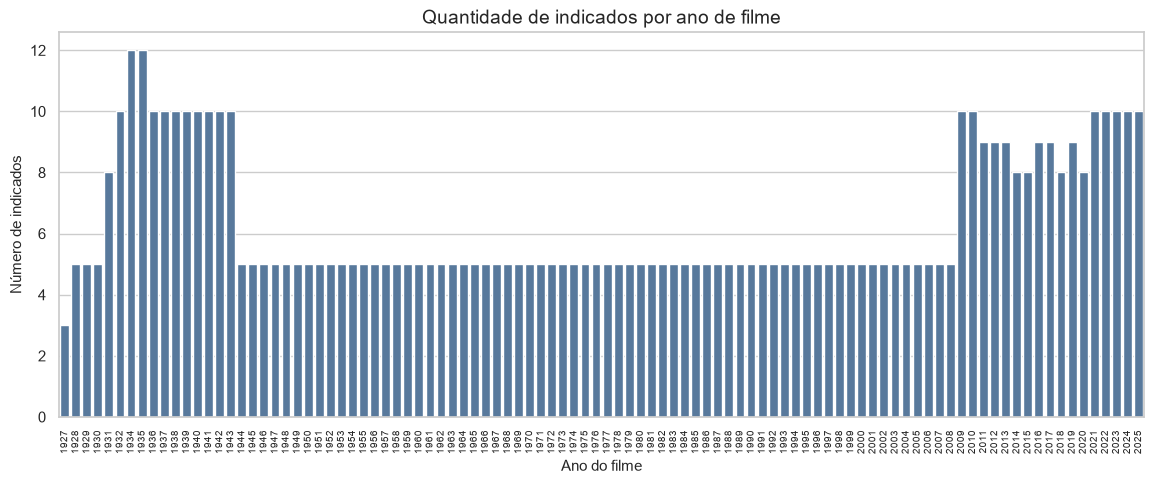

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=coverage_by_year, x="year_film", y="nominees", color="#4C78A8", ax=ax)
ax.set_title("Quantidade de indicados por ano de filme")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Número de indicados")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.show()

## 6. Distribuição das durações

A distribuição geral mostra o centro, dispersão e presença de filmes muito curtos ou muito longos dentro da proxy analisada.

In [12]:
runtime_summary = analysis_df["runtime_minutes"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
runtime_summary.to_frame("runtime_minutes")

,runtime_minutes
count,621.00
mean,126.79
std,27.56
min,65.00
1%,84.00
5%,90.00
25%,107.00
50%,122.00
75%,139.00
95%,181.00


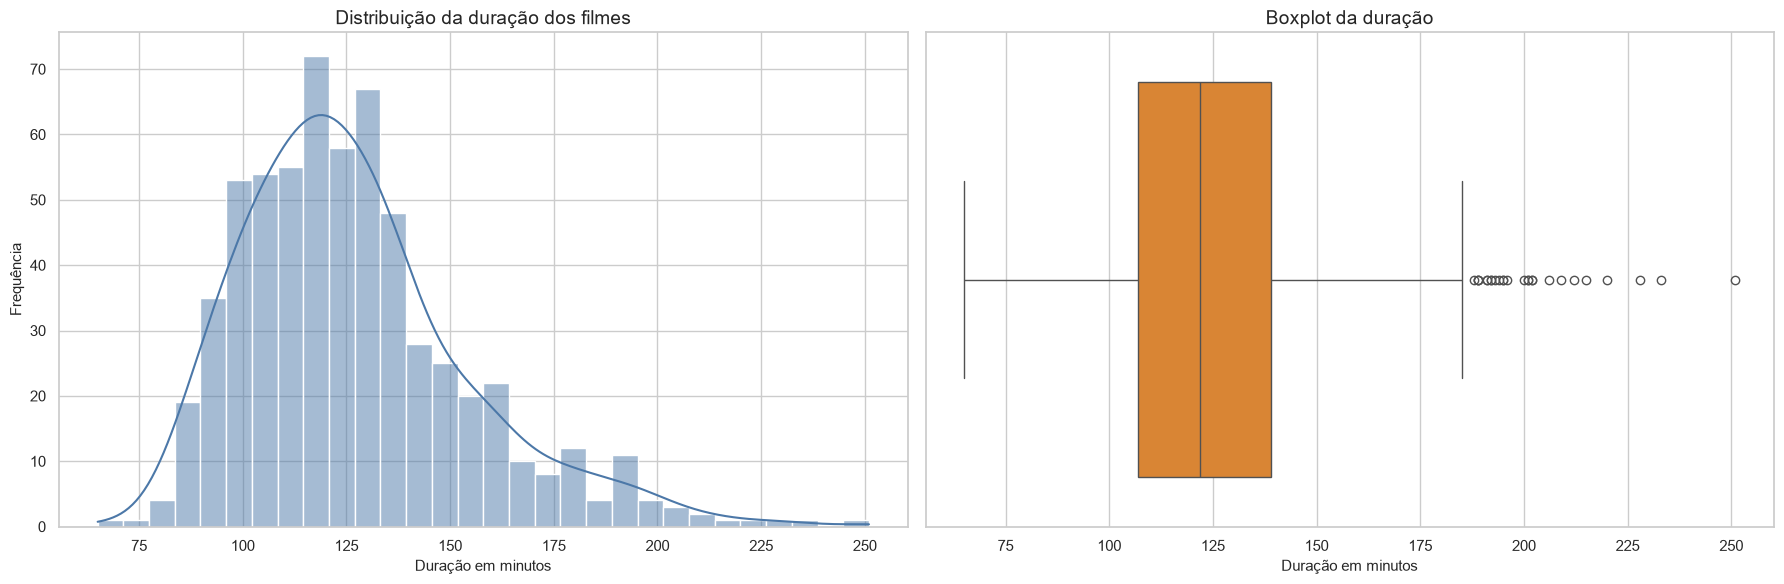

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(analysis_df["runtime_minutes"], bins=30, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribuição da duração dos filmes")
axes[0].set_xlabel("Duração em minutos")
axes[0].set_ylabel("Frequência")

sns.boxplot(data=analysis_df, x="runtime_minutes", ax=axes[1], color="#F58518")
axes[1].set_title("Boxplot da duração")
axes[1].set_xlabel("Duração em minutos")
plt.tight_layout()
plt.show()

In [14]:
shortest = analysis_df.nsmallest(10, "runtime_minutes")[["year_film", "film", "winner", "runtime_minutes"]]
longest = analysis_df.nlargest(10, "runtime_minutes")[["year_film", "film", "winner", "runtime_minutes"]]
shortest, longest

(     year_film                        film  winner  runtime_minutes
 33        1932          She Done Him Wrong   False               65
 137       1943         The Ox-Bow Incident   False               76
 23        1931           One Hour with You   False               80
 47        1934            The White Parade   False               80
 24        1931            Shanghai Express   False               82
 13        1930                    Cimarron    True               83
 44        1934           One Night of Love   False               84
 69        1936           Three Smart Girls   False               84
 77        1937  One Hundred Men and a Girl   False               84
 375       1991        Beauty and the Beast   False               84,
      year_film                        film  winner  runtime_minutes
 236       1963                   Cleopatra   False              251
 91        1939          Gone with the Wind    True              233
 230       1962          Lawrence

## 7. Comparações por década e resultado

As agregações por década reduzem ruído anual e ajudam a identificar mudanças históricas no padrão de duração.

In [15]:
decade_summary = (
    analysis_df.groupby("decade", as_index=False)
    .agg(
        nominees=("film", "count"),
        winners=("winner", "sum"),
        runtime_mean=("runtime_minutes", "mean"),
        runtime_median=("runtime_minutes", "median"),
        runtime_std=("runtime_minutes", "std"),
        runtime_min=("runtime_minutes", "min"),
        runtime_max=("runtime_minutes", "max"),
    )
)
decade_summary

,decade,nominees,winners,runtime_mean,runtime_median,runtime_std,runtime_min,runtime_max
0,1920,13,3,107.46,101.00,20.04,88,147
1,1930,87,9,105.48,102.00,22.50,65,233
2,1940,70,10,118.60,118.00,20.31,76,177
3,1950,50,10,128.38,119.00,31.30,85,220
4,1960,50,10,144.38,138.50,33.95,94,251
5,1970,50,10,130.42,122.00,28.59,93,202
6,1980,50,10,127.96,122.00,24.48,92,195
7,1990,50,10,137.48,135.00,26.61,84,195
8,2000,55,10,132.00,129.00,24.07,92,201
9,2010,88,10,126.32,126.50,20.61,89,209


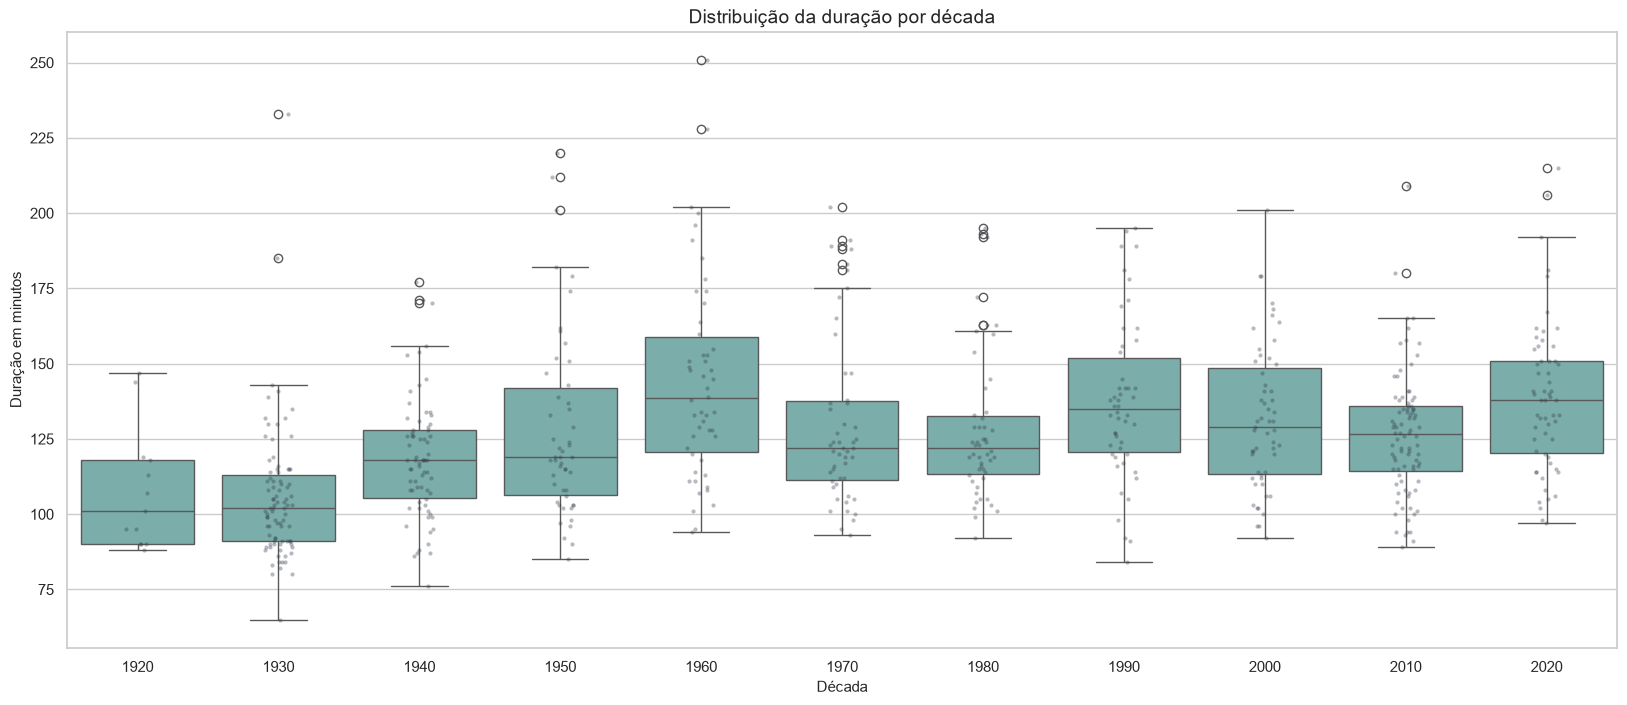

In [16]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.boxplot(data=analysis_df, x="decade", y="runtime_minutes", color="#72B7B2", ax=ax)
sns.stripplot(
    data=analysis_df,
    x="decade",
    y="runtime_minutes",
    color="#2F3A4A",
    alpha=0.35,
    size=3,
    ax=ax,
)
ax.set_title("Distribuição da duração por década")
ax.set_xlabel("Década")
ax.set_ylabel("Duração em minutos")
plt.show()

In [17]:
result_summary = (
    analysis_df.groupby("winner_label", as_index=False)
    .agg(
        filmes=("film", "count"),
        runtime_mean=("runtime_minutes", "mean"),
        runtime_median=("runtime_minutes", "median"),
        runtime_std=("runtime_minutes", "std"),
    )
)
result_summary

,winner_label,filmes,runtime_mean,runtime_median,runtime_std
0,Indicado,523,124.72,121.00,26.23
1,Vencedor,98,137.84,130.00,31.72


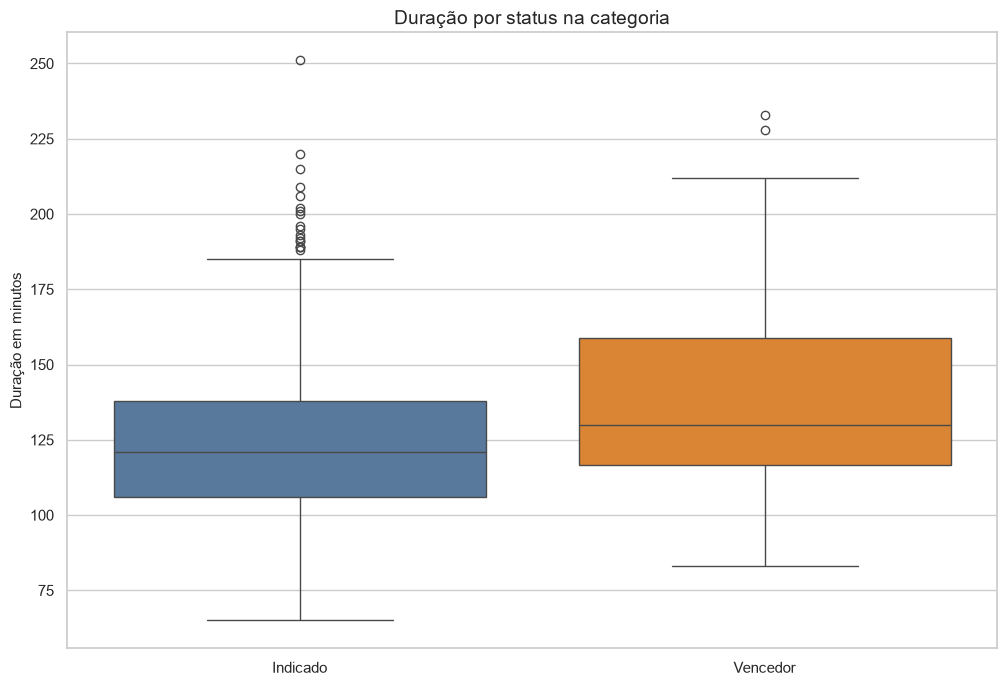

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(
    data=analysis_df,
    x="winner_label",
    y="runtime_minutes",
    hue="winner_label",
    palette={"Indicado": "#4C78A8", "Vencedor": "#F58518"},
    legend=False,
    ax=ax,
)
ax.set_title("Duração por status na categoria")
ax.set_xlabel("")
ax.set_ylabel("Duração em minutos")
plt.show()

## 8. Relação inicial entre ano e duração

Esta visão não substitui a modelagem estatística, mas indica se há associação visual entre tempo histórico e duração dos filmes.

In [19]:
correlation = analysis_df[["year_film", "runtime_minutes"]].corr(method="pearson").loc["year_film", "runtime_minutes"]
spearman = analysis_df[["year_film", "runtime_minutes"]].corr(method="spearman").loc["year_film", "runtime_minutes"]

pd.DataFrame(
    {
        "métrica": ["correlação de Pearson", "correlação de Spearman"],
        "valor": [correlation, spearman],
    }
)

,métrica,valor
0,correlação de Pearson,0.27
1,correlação de Spearman,0.36


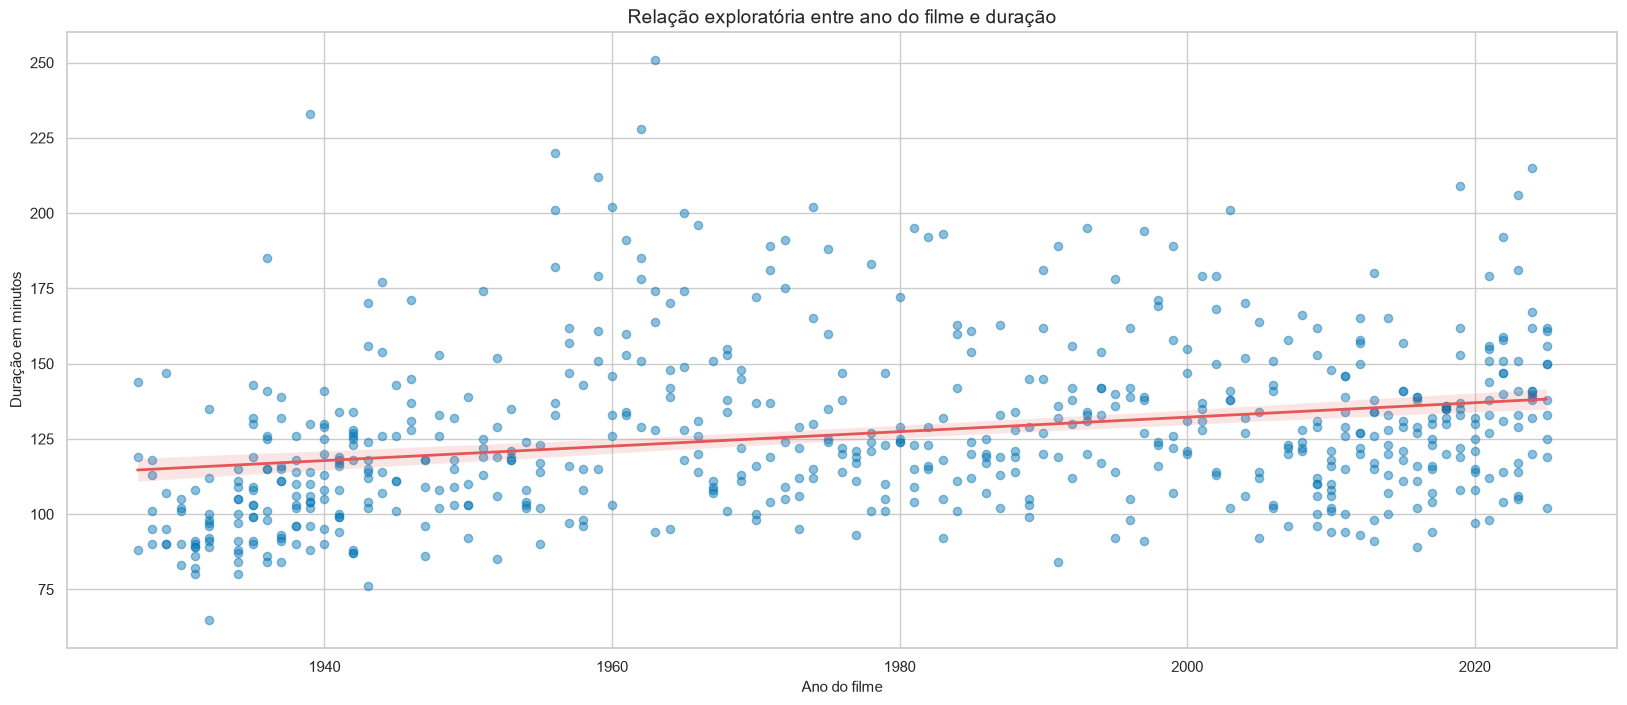

In [20]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.regplot(
    data=analysis_df,
    x="year_film",
    y="runtime_minutes",
    scatter_kws={"alpha": 0.45, "s": 35},
    line_kws={"color": "#E45756", "linewidth": 2},
    ax=ax,
)
ax.set_title("Relação exploratória entre ano do filme e duração")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
plt.show()

## 9. Leituras preliminares

- A camada gold está pronta para EDA quando `year_film`, `film`, `winner`, `runtime_minutes`, `runtime_source` e `tmdb_id` estão completos.
- A granularidade operacional é uma linha por filme indicado ao Oscar de Melhor Filme em um ano específico.
- A análise deve ser interpretada como evidência sobre a proxy de indicados ao Oscar, não como conclusão universal sobre todos os filmes.
- Para responder formalmente à hipótese do projeto, o próximo passo é ajustar e diagnosticar uma regressão entre `year_film` e `runtime_minutes`.